In [2]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency


In [3]:
#spot perfect (and weak) association

# Cramér’s V: Effect size measure for association between two nominal variables (0 = no association, 1 = perfect association).
# Based on chi-square statistic.

def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    r, k = ct.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

df = pd.read_parquet('data/votersurvey_cleaned.parquet')
target = df['PARTY_AGENDAS_rand_2016']
features = df.drop(columns=['PARTY_AGENDAS_rand_2016'])

scores = {}
for col in features.columns:
    try:
        scores[col] = cramers_v(features[col].astype(str), target.astype(str))
    except:
        scores[col] = 0

ranked = pd.Series(scores).sort_values(ascending=False)
print(ranked.head(40))  # Top 20 — anything > 0.7 is suspicious

# Nothing seems to associate to well, exept izip_2016 of course
# But it's interesting that the fealing thermometer's "seem" to be good predictors (let's see...)


/tmp/ipykernel_713/2008607889.py:11: RuntimeWarning: invalid value encountered in divide
  return np.sqrt(chi2 / (n * (min(r, k) - 1)))
/tmp/ipykernel_713/2008607889.py:11: RuntimeWarning: invalid value encountered in divide
  return np.sqrt(chi2 / (n * (min(r, k) - 1)))


izip_2016               0.927177
ft_fem_2016             0.209105
ft_white_2016           0.202903
ft_police_2016          0.198087
ft_immig_2016           0.197657
ft_muslim_2016          0.190375
ft_unions_2016          0.189834
ft_wallst_2016          0.188460
ft_blm_2016             0.182428
ft_black_2016           0.181755
ft_altright_2016        0.176793
ft_christ_2016          0.176671
ft_hisp_2016            0.176318
ft_asian_2016           0.175006
ft_jew_2016             0.173847
ft_gays_2016            0.162371
inputstate_2016         0.129687
faminc_2016             0.087096
religpew_2016           0.069385
obamaapp_2016           0.065394
pew_churatd_2016        0.064573
ideo5_2016              0.062409
amwhite_2016            0.061620
pew_prayer_2016         0.055904
fav_obama_2016          0.055687
amenglish_2016          0.055470
imiss_t_2016            0.055042
RIGGED_SYSTEM_3_2016    0.054622
employ_2016             0.054548
fav_sanders_2016        0.053080
immi_musli

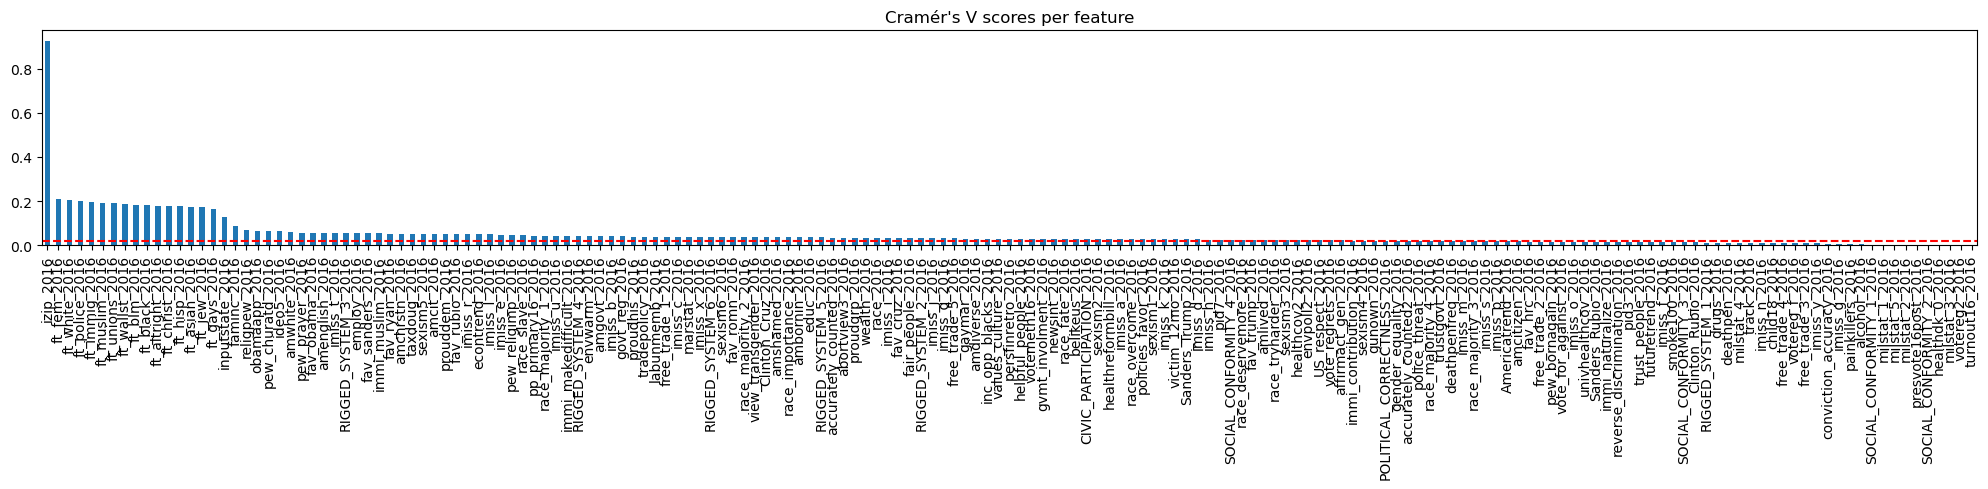

In [4]:
import matplotlib.pyplot as plt

# ellbow method: to decide the threshold to drop columns

ranked.plot(kind='bar', figsize=(20, 5))
plt.axhline(y=0.02, color='red', linestyle='--')
plt.title('Cramér\'s V scores per feature')
plt.tight_layout()
plt.show()

# Because there is no rule where to cut really, I would just try out different thresholds and give it to the model
# If we sould cut just at the "ellbow" we would only have around 18 features left...
# I just decide a cutting line, where around 25% of the features remain (cut at < 0.05)


In [5]:
# keep features above 0.05 Cramér's V
to_keep = ranked[ranked > 0.05].index.tolist()

# add target back
to_keep.append('PARTY_AGENDAS_rand_2016')

df_selected = df[to_keep] #df_selected is the feature-reduced df
print(df_selected.shape)

(2861, 41)


In [6]:
#drop known artifact

# find constant columns (only 1 answer type)
for col in df.columns:
    if df[col].nunique() <= 1:
        print(col)

        
#drop the corresponding columns + the zipcode
df = df.drop(columns=['izip_2016', "votereg2_2016","turnout16_2016"])

votereg2_2016
turnout16_2016


In [7]:
%pip install lightgbm

Note: you may need to restart the kernel to use updated packages.


In [8]:
# try out

import pandas as pd
import numpy as np
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
import lightgbm as lgb

# ── Prepare data ────────────────────────────────────────────────────


target = 'PARTY_AGENDAS_rand_2016'

X = df.drop(columns=[target])
y = (df[target] == 'Republican Party').astype(int)


# ── Encode categoricals → numbers (both models need this) ───────────
cat_cols   = X.select_dtypes(include='category').columns.tolist()
float_cols = X.select_dtypes(include='float64').columns.tolist()

enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X[cat_cols] = enc.fit_transform(X[cat_cols])

# ── Train/test split ────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── Logistic Regression (needs scaling) ─────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)

print("── Logistic Regression ──")
print(classification_report(y_test, lr.predict(X_test_sc)))
print("ROC-AUC:", round(roc_auc_score(y_test, lr.predict_proba(X_test_sc)[:, 1]), 4))

# ── LightGBM (no scaling needed) ────────────────────────────────────
lgbm = lgb.LGBMClassifier(n_estimators=500, learning_rate=0.05,
                           max_depth=6, random_state=42, verbose=-1)
lgbm.fit(X_train, y_train,
         eval_set=[(X_test, y_test)],
         callbacks=[lgb.early_stopping(50, verbose=False)])

print("\n── LightGBM ──")
print(classification_report(y_test, lgbm.predict(X_test)))
print("ROC-AUC:", round(roc_auc_score(y_test, lgbm.predict_proba(X_test)[:, 1]), 4))

── Logistic Regression ──
              precision    recall  f1-score   support

           0       0.50      0.46      0.48       276
           1       0.53      0.57      0.55       297

    accuracy                           0.51       573
   macro avg       0.51      0.51      0.51       573
weighted avg       0.51      0.51      0.51       573

ROC-AUC: 0.507

── LightGBM ──
              precision    recall  f1-score   support

           0       0.50      0.13      0.20       276
           1       0.52      0.88      0.66       297

    accuracy                           0.52       573
   macro avg       0.51      0.50      0.43       573
weighted avg       0.51      0.52      0.44       573

ROC-AUC: 0.4954


In [9]:
# try out

import pandas as pd
import numpy as np
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
import lightgbm as lgb

# ── Prepare data ────────────────────────────────────────────────────
target = 'PARTY_AGENDAS_rand_2016'

X = df.drop(columns=[target])
y = (df[target] == 'Republican Party').astype(int)


# ── Encode categoricals → numbers (both models need this) ───────────
cat_cols   = X.select_dtypes(include='category').columns.tolist()
float_cols = X.select_dtypes(include='float64').columns.tolist()

enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X[cat_cols] = enc.fit_transform(X[cat_cols])

# ── Train/test split ────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── Logistic Regression (needs scaling) ─────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)

print("── Logistic Regression ──")
print(classification_report(y_test, lr.predict(X_test_sc)))
print("ROC-AUC:", round(roc_auc_score(y_test, lr.predict_proba(X_test_sc)[:, 1]), 4))

# ── LightGBM (no scaling needed) ────────────────────────────────────
lgbm = lgb.LGBMClassifier(n_estimators=500, learning_rate=0.05,
                           max_depth=6, random_state=42, verbose=-1)
lgbm.fit(X_train, y_train,
         eval_set=[(X_test, y_test)],
         callbacks=[lgb.early_stopping(50, verbose=False)])

print("\n── LightGBM ──")
print(classification_report(y_test, lgbm.predict(X_test)))
print("ROC-AUC:", round(roc_auc_score(y_test, lgbm.predict_proba(X_test)[:, 1]), 4))

── Logistic Regression ──
              precision    recall  f1-score   support

           0       0.50      0.46      0.48       276
           1       0.53      0.57      0.55       297

    accuracy                           0.51       573
   macro avg       0.51      0.51      0.51       573
weighted avg       0.51      0.51      0.51       573

ROC-AUC: 0.507

── LightGBM ──
              precision    recall  f1-score   support

           0       0.50      0.13      0.20       276
           1       0.52      0.88      0.66       297

    accuracy                           0.52       573
   macro avg       0.51      0.50      0.43       573
weighted avg       0.51      0.52      0.44       573

ROC-AUC: 0.4954
